# Sales Forecasting for Retail Decision-Making  
## A Business Intelligence Case Study Using Walmart Sales Data  

**Module:** Business Intelligence and Data Mining (UFCFMM)  
**Assessment:** Group Project Portfolio  
**Team Members:** [Add Names]  
**Dataset Source:** Kaggle – Walmart Sales Dataset  

---

## 1. Executive Summary

## 2. Business Context & Problem Definition


## 3. Dataset Description & Justification

## 4. Technical Setup & Data Loading

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Walmart.csv")

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## 5. Data Quality Assessment


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [4]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [5]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


### Data Quality Summary

The dataset contains 6,435 observations across 45 Walmart stores, with 8 variables describing weekly sales and related economic indicators.

No missing values were detected across any variables, indicating a complete dataset suitable for modelling without imputation.

Weekly sales range from approximately £209,986 to £3,818,686, with an average weekly sales value of approximately £1,046,965. This substantial variability highlights the operational importance of accurate demand forecasting in large retail environments.

All economic indicators (Temperature, Fuel Price, CPI, and Unemployment) appear numerically consistent and require no immediate cleaning. However, the Date variable was initially stored as a string and has been converted to datetime format to enable time series analysis.


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [7]:
df.isnull().sum()


Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [8]:
df.describe()


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


## 6. Exploratory Data Analysis (EDA)


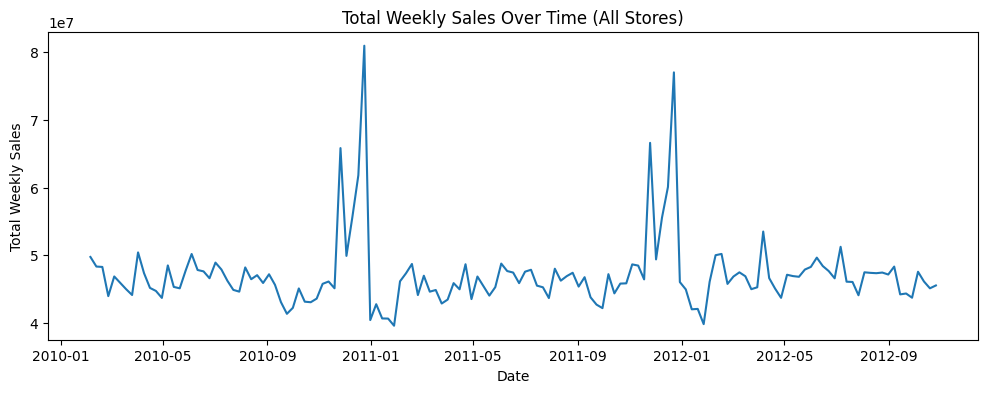

In [5]:
plt.figure(figsize=(12,4))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'])
plt.title("Total Weekly Sales Over Time (All Stores)")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.show()


### Time-Series Trend Insight

The aggregated weekly sales exhibit substantial volatility over time, with most weeks falling between approximately £40–50 million in total revenue.

Two pronounced spikes are visible in late 2010 and late 2011, likely corresponding to peak holiday shopping periods. These seasonal surges are followed by sharp declines, suggesting post-holiday demand contraction.

The presence of clear seasonal peaks indicates that holiday effects play a significant role in sales variation, reinforcing the need to incorporate temporal and seasonal features into forecasting models.


In [6]:
# Extract holiday flag per date (since it's consistent across stores)
holiday_info = df[['Date', 'Holiday_Flag']].drop_duplicates()

# Merge with weekly total
weekly_total = weekly_total.merge(holiday_info, on='Date')

weekly_total.head()


,Date,Weekly_Sales,Holiday_Flag
0,2010-02-05,49750740.50,0
1,2010-02-12,48336677.63,1
2,2010-02-19,48276993.78,0
3,2010-02-26,43968571.13,0
4,2010-03-05,46871470.30,0


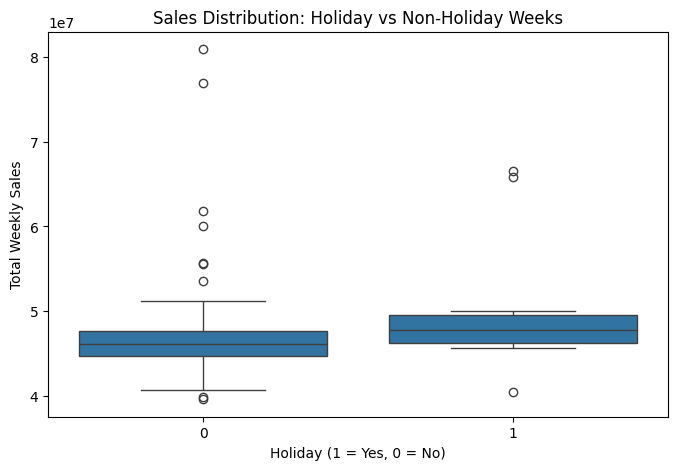

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=weekly_total)

plt.title("Sales Distribution: Holiday vs Non-Holiday Weeks")
plt.xlabel("Holiday (1 = Yes, 0 = No)")
plt.ylabel("Total Weekly Sales")
plt.show()


### Holiday Effect Analysis

Holiday weeks exhibit a slightly higher median sales level compared to non-holiday weeks. However, the difference is not substantial across the majority of observations.

While certain holiday weeks generate extreme sales spikes (as shown by high-value outliers), most holiday weeks display sales levels similar to regular weeks. This suggests that although holiday effects contribute to demand increases, broader seasonal patterns (particularly in late-year months) likely play a more significant role in driving peak sales.

This finding indicates that relying solely on the Holiday_Flag variable may be insufficient for capturing full seasonal dynamics in forecasting models.


## 7. Feature Engineering & Preprocessing


In [3]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.3 KB


In [4]:
# Aggregate total weekly sales across all stores
weekly_total = (
    df.groupby('Date', as_index=False)['Weekly_Sales']
      .sum()
      .sort_values('Date')
)

weekly_total.head()


,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


## 8. Baseline Forecast Model


## 9. Forecasting Models


## 10. Model Evaluation (Technical & Business)


## 11. Strategic Recommendations


## 12. Ethical, Privacy & Security Evaluation


## 13. Conclusion


## 14. References
